In [32]:
### OPTIMISATION OF FRAUD DETECTION APPLYING BAYES MINIMUM RISK TO ML MODELS

In [6]:
#Step 1: Imports & Memory Optimization
import pandas as pd
import numpy as np

def reduce_mem_usage(df):
    """
    Iterates through all columns of a dataframe and modifies the data type
    to reduce memory usage.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')

    return df

In [7]:
# Srep 2: Loading, Merging, and Dropping Missing Values
#1. Load the data
print("Loading data...")
train_transaction = pd.read_csv('/content/train_transaction.csv')
train_identity = pd.read_csv('/content/train_identity.csv')

# 2. Merge using a Left Join on TransactionID
print("Merging data...")
train_df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# 3. Optimize Memory
print("Optimizing memory...")
train_df = reduce_mem_usage(train_df)

# 4. Clean Missing Values (The 80% Rule)
print("Dropping columns with > 80% missing values...")
# Calculate the percentage of missing values for each column
missing_percentages = train_df.isnull().sum() / len(train_df)

# Identify columns where less than 80% of the data is missing
columns_to_keep = missing_percentages[missing_percentages < 0.80].index

# Overwrite the dataframe with only the robust columns
train_df = train_df[columns_to_keep]

print(f"Final dataset shape after cleaning: {train_df.shape}")

Loading data...
Merging data...
Optimizing memory...
Memory usage of dataframe is 1955.37 MB


/tmp/ipykernel_1509/3573623451.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_1509/3573623451.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_1509/3573623451.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_1509/3573623451.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_1509/3573623451.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_1509/3573623451.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_1509/3573623451.py:29: RuntimeW

Memory usage after optimization is: 645.97 MB
Decreased by 67.0%
Dropping columns with > 80% missing values...
Final dataset shape after cleaning: (590540, 360)


In [8]:
# The Time-Based Hold-Out Split
#TransactionDT is a time-delta from a given reference datetime (not an actual timestamp). By sorting the dataframe by this column, we arrange all transactions chronologically.
# 1. Sort the dataset chronologically
train_df = train_df.sort_values('TransactionDT').reset_index(drop=True)

# 2. Define the split indices
total_rows = len(train_df)
train_end = int(total_rows * 0.70)  # 70% for Training
val_end = int(total_rows * 0.85)    # 15% for Validation

# 3. Slice the dataframes
train_set = train_df.iloc[:train_end].copy()
validation_set = train_df.iloc[train_end:val_end].copy()
local_test_set = train_df.iloc[val_end:].copy()

# 4. Verify the splits
print(f"Training Set: {len(train_set)} rows ({len(train_set)/total_rows:.1%})")
print(f"Validation Set: {len(validation_set)} rows ({len(validation_set)/total_rows:.1%})")
print(f"Local Test Set: {len(local_test_set)} rows ({len(local_test_set)/total_rows:.1%})")

# Let's check the fraud rate in our hold-out test set
fraud_rate = local_test_set['isFraud'].mean() * 100
print(f"\nFraud Rate in Local Test Set: {fraud_rate:.2f}%")
#1. Sort the dataset chronologically
train_df = train_df.sort_values('TransactionDT').reset_index(drop=True)

# 2. Define the split indices
total_rows = len(train_df)
train_end = int(total_rows * 0.70)  # 70% for Training
val_end = int(total_rows * 0.85)    # 15% for Validation

# 3. Slice the dataframes
train_set = train_df.iloc[:train_end].copy()
validation_set = train_df.iloc[train_end:val_end].copy()
local_test_set = train_df.iloc[val_end:].copy()

# 4. Verify the splits
print(f"Training Set: {len(train_set)} rows ({len(train_set)/total_rows:.1%})")
print(f"Validation Set: {len(validation_set)} rows ({len(validation_set)/total_rows:.1%})")
print(f"Local Test Set: {len(local_test_set)} rows ({len(local_test_set)/total_rows:.1%})")

# Let's check the fraud rate in our hold-out test set
fraud_rate = local_test_set['isFraud'].mean() * 100
print(f"\nFraud Rate in Local Test Set: {fraud_rate:.2f}%")

Training Set: 413378 rows (70.0%)
Validation Set: 88581 rows (15.0%)
Local Test Set: 88581 rows (15.0%)

Fraud Rate in Local Test Set: 3.48%
Training Set: 413378 rows (70.0%)
Validation Set: 88581 rows (15.0%)
Local Test Set: 88581 rows (15.0%)

Fraud Rate in Local Test Set: 3.48%


In [33]:
### EDA

In [37]:
# 1. Calculate the Grand Total
total_volume = ltv_results_df['TransactionAmt'].sum()
print(f"Grand Total Transaction Volume: ${total_volume:,.2f}")

# 2. Calculate the Total Volume by Fraud Status (0 = Legitimate, 1 = Fraud)
volume_breakdown = ltv_results_df.groupby('isFraud')['TransactionAmt'].sum()

print("\n--- Volume Breakdown ---")
print(f"Total Legitimate Volume: ${volume_breakdown[0]:,.2f}")
print(f"Total Fraudulent Volume: ${volume_breakdown[1]:,.2f}")

Grand Total Transaction Volume: $12,148,743.06

--- Volume Breakdown ---
Total Legitimate Volume: $11,679,136.62
Total Fraudulent Volume: $469,606.45


Calculating Class Imbalance...
Legitimate (0): 96.48%
Fraudulent (1): 3.52%



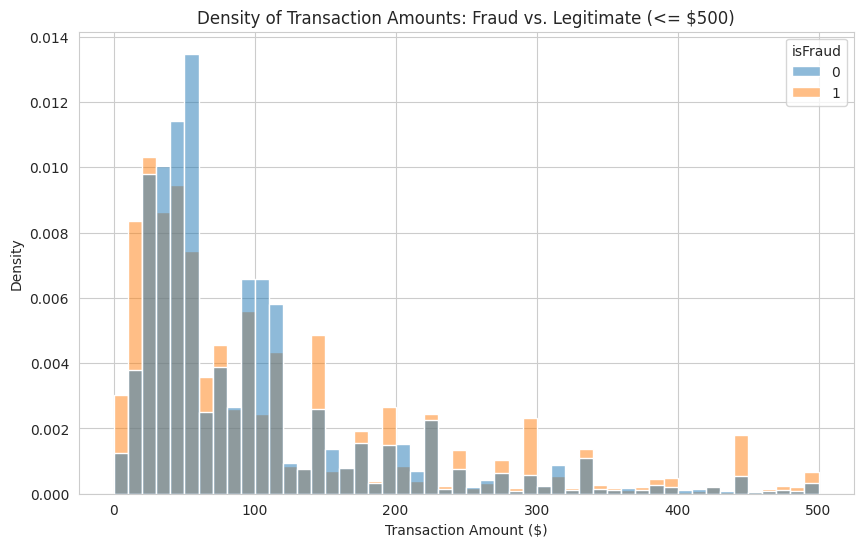

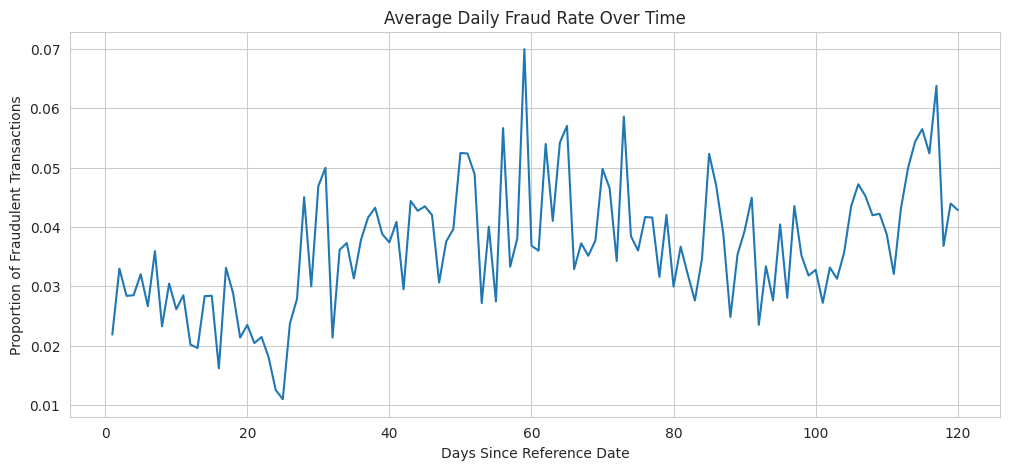

In [9]:
#We will look at three key areas: the baseline fraud rate, how transaction amounts differ between legitimate and fraudulent purchases, and the temporal (time-based) behavior of fraudsters.

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_style("whitegrid")

# 1. The Imbalance (Baseline Fraud Rate)
print("Calculating Class Imbalance...")
fraud_counts = train_set['isFraud'].value_counts(normalize=True) * 100
print(f"Legitimate (0): {fraud_counts[0]:.2f}%")
print(f"Fraudulent (1): {fraud_counts[1]:.2f}%\n")

# 2. Transaction Amount Distribution (The Micro-Transaction Hypothesis)
# We limit the x-axis to $500 because the data has massive extreme outliers
plt.figure(figsize=(10, 6))
sns.histplot(data=train_set[train_set['TransactionAmt'] <= 500],
             x='TransactionAmt',
             hue='isFraud',
             stat='density',
             common_norm=False,
             bins=50,
             alpha=0.5)
plt.title('Density of Transaction Amounts: Fraud vs. Legitimate (<= $500)')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Density')
plt.show()

# 3. Time-Series Behavior (Fraud over the days)
# TransactionDT is in seconds. We convert it to days to see daily volume.
train_set['TransactionDay'] = np.floor(train_set['TransactionDT'] / (3600 * 24))

plt.figure(figsize=(12, 5))
train_set.groupby('TransactionDay')['isFraud'].mean().plot()
plt.title('Average Daily Fraud Rate Over Time')
plt.xlabel('Days Since Reference Date')
plt.ylabel('Proportion of Fraudulent Transactions')
plt.show()

/tmp/ipykernel_1509/720105940.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=card_type_fraud.index, y=card_type_fraud.values, palette='viridis')


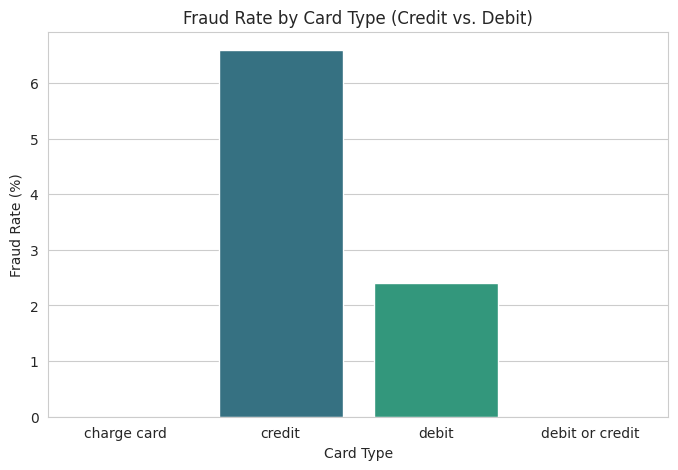

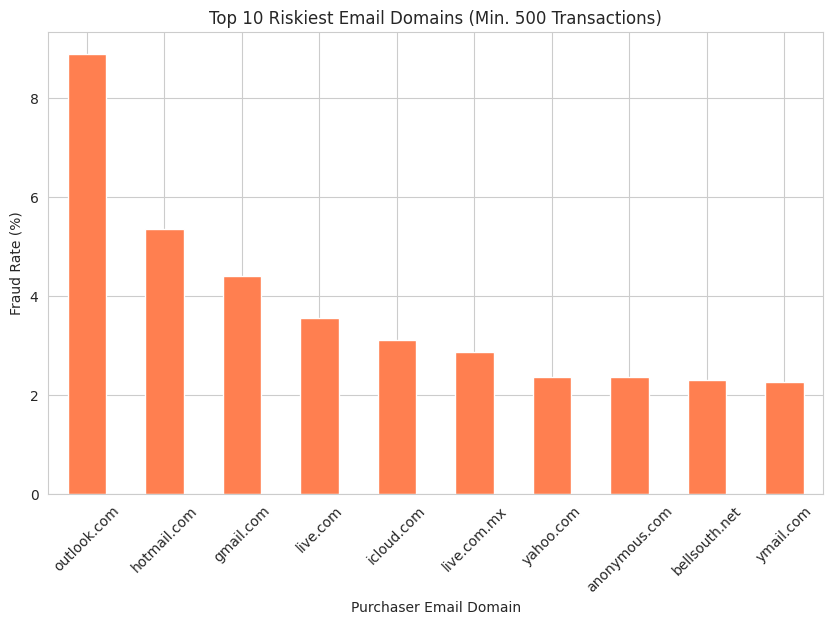

/tmp/ipykernel_1509/720105940.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_fraud.index, y=missing_fraud.values, palette='Set2')


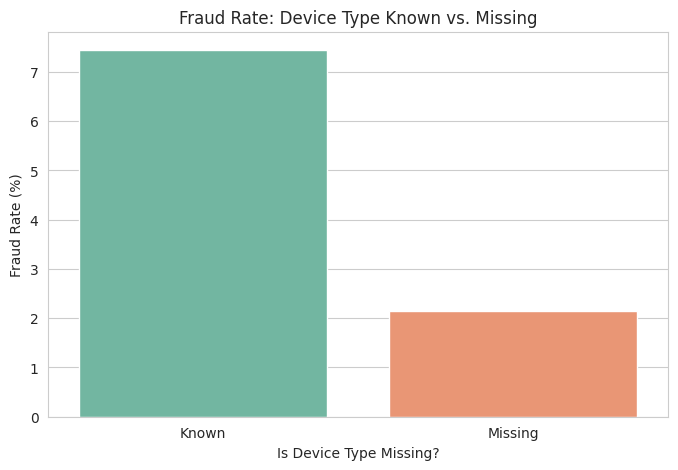

In [10]:
# 1. Credit vs. Debit Fraud Rates
plt.figure(figsize=(8, 5))
# Calculate the mean fraud rate for each card type, convert to percentage
card_type_fraud = train_set.groupby('card6')['isFraud'].mean() * 100
sns.barplot(x=card_type_fraud.index, y=card_type_fraud.values, palette='viridis')
plt.title('Fraud Rate by Card Type (Credit vs. Debit)')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Card Type')
plt.show()

# 2. Top 10 Riskiest Email Domains
plt.figure(figsize=(10, 6))
# Filter to domains with at least 500 transactions to remove noise
email_counts = train_set['P_emaildomain'].value_counts()
valid_emails = email_counts[email_counts > 500].index
email_fraud = train_set[train_set['P_emaildomain'].isin(valid_emails)].groupby('P_emaildomain')['isFraud'].mean() * 100
# Sort and take the top 10 highest fraud rates
email_fraud.sort_values(ascending=False).head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Riskiest Email Domains (Min. 500 Transactions)')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Purchaser Email Domain')
plt.xticks(rotation=45)
plt.show()

# 3. Missingness as a Feature (Example using DeviceType)
plt.figure(figsize=(8, 5))
# Create a temporary column to flag if DeviceType is missing
train_set['DeviceType_is_Missing'] = train_set['DeviceType'].isnull()
missing_fraud = train_set.groupby('DeviceType_is_Missing')['isFraud'].mean() * 100
sns.barplot(x=missing_fraud.index, y=missing_fraud.values, palette='Set2')
plt.title('Fraud Rate: Device Type Known vs. Missing')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Is Device Type Missing?')
plt.xticks(ticks=[0, 1], labels=['Known', 'Missing'])
plt.show()

In [11]:
#FEATURE ENGINEERING


In [12]:
#It is time to extract the predictive signals.
#Raw data rarely feeds well into advanced models without some mathematical transformation.
# We will create three specific sets of features: cyclical time, velocity, and centered continuous variables.

import numpy as np

# 1. Cyclical Time Features
print("Engineering cyclical time features...")
# TransactionDT is in seconds. There are 3600 seconds in an hour and 86400 in a day.
train_set['Hour'] = np.floor(train_set['TransactionDT'] / 3600) % 24
train_set['DayOfWeek'] = np.floor(train_set['TransactionDT'] / 86400) % 7

# If we leave Hour as 0-23, the model thinks 23 (11 PM) and 0 (Midnight) are far apart.
# We use sine and cosine to map the hours onto a circle, preserving their true proximity.
train_set['Hour_sin'] = np.sin(2 * np.pi * train_set['Hour'] / 24)
train_set['Hour_cos'] = np.cos(2 * np.pi * train_set['Hour'] / 24)

# 2. Velocity / Frequency Metrics
print("Engineering velocity metrics...")
# We measure how aggressively a specific card is being used in the dataset.
# We map the frequency count of each 'card1' ID back to the rows.
# Explicitly cast 'card1' to float64 to avoid 'float16 indexes are not supported' error when creating the dictionary
card1_counts = train_set['card1'].astype(np.float64).value_counts().to_dict()
# Explicitly cast 'card1' to float64 before mapping to avoid 'float16 indexes are not supported' error
train_set['card1_frequency'] = train_set['card1'].astype(np.float64).map(card1_counts)

# Same logic for email domains to catch botnets using burner emails
email_counts = train_set['P_emaildomain'].value_counts().to_dict()
train_set['email_frequency'] = train_set['P_emaildomain'].map(email_counts).fillna(0)

# 3. Econometric Centering
print("Centering continuous variables...")
# To maintain a rigorous baseline and ensure clean coefficient interpretation
# for any linear modeling, we calculate the difference from the sample mean.
mean_txn_amt = train_set['TransactionAmt'].mean()
train_set['TransactionAmt_centered'] = train_set['TransactionAmt'] - mean_txn_amt

mean_card1_freq = train_set['card1_frequency'].mean()
train_set['card1_frequency_centered'] = train_set['card1_frequency'] - mean_card1_freq

print(f"Feature engineering complete. Current columns: {train_set.shape[1]}")

Engineering cyclical time features...
Engineering velocity metrics...
Centering continuous variables...
Feature engineering complete. Current columns: 370


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan


In [13]:
#Transforming the Out-of-Sample Data
#Engineering the features on our validation_set and local_test_set using the parameters strictly learned from the train_set.

def apply_feature_engineering(df, card1_dict, email_dict, mean_txn, mean_card1):
    """Applies training-set transformations to unseen data."""
    # 1. Cyclical Time Features
    df['Hour'] = np.floor(df['TransactionDT'] / 3600) % 24
    df['DayOfWeek'] = np.floor(df['TransactionDT'] / 86400) % 7
    df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

    # 2. Velocity Metrics (Using training dictionaries)
    # If a card or email was never seen in training, we fillna(0)
    # Explicitly cast 'card1' to float64 before mapping to avoid 'float16 indexes are not supported' error
    df['card1_frequency'] = df['card1'].astype(np.float64).map(card1_dict).fillna(0)
    df['email_frequency'] = df['P_emaildomain'].map(email_dict).fillna(0)

    # 3. Econometric Centering (Using training means)
    df['TransactionAmt_centered'] = df['TransactionAmt'] - mean_txn
    df['card1_frequency_centered'] = df['card1_frequency'] - mean_card1

    return df

print("Transforming Validation Set...")
validation_set = apply_feature_engineering(validation_set, card1_counts, email_counts, mean_txn_amt, mean_card1_freq)

print("Transforming Local Test Set...")
local_test_set = apply_feature_engineering(local_test_set, card1_counts, email_counts, mean_txn_amt, mean_card1_freq)

Transforming Validation Set...
Transforming Local Test Set...


In [34]:
## TRAIN-TEST SPLIT

In [14]:
#Preparing the Features (X) and Target (y)
#Before feeding the data to the model, we must isolate the target variable (isFraud) and drop irrelevant columns.

# Define the target variable
target = 'isFraud'

# Drop raw categorical strings, IDs, and uncentered variables to keep the baseline clean
cols_to_drop = [
    'isFraud', 'TransactionID', 'TransactionDT', 'Hour',
    'P_emaildomain', 'DeviceInfo', 'DeviceType', 'ProductCD',
    'card4', 'card6', 'TransactionAmt', 'card1_frequency'
]

# Keep only the numeric and engineered features
# First, identify all potential features from the train_set that are not in cols_to_drop
all_potential_features = [col for col in train_set.columns if col not in cols_to_drop]

# Then, filter these features to only include those present in all data splits
# This handles the case where some features were added only to train_set (e.g., for EDA)
common_features = list(set(all_potential_features) & set(validation_set.columns) & set(local_test_set.columns))

# Also drop any remaining 'object' dtype columns to avoid algorithm errors
features = [col for col in common_features if train_set[col].dtype != 'object']

X_train = train_set[features]
y_train = train_set[target]

X_val = validation_set[features]
y_val = validation_set[target]

X_test = local_test_set[features]
y_test = local_test_set[target]

print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Test features shape: {X_test.shape}")

Training features shape: (413378, 336)
Validation features shape: (88581, 336)
Test features shape: (88581, 336)


In [15]:
# TRAINING THE GB MODELS

In [ ]:
#LightGBM.
# It builds trees efficiently on large datasets and handles any remaining NaN values natively, which is perfect for this matrix.
import lightgbm as lgb

print("Initializing LightGBM Model...")
# We use standard binary log-loss for the initial probability estimation
clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    objective='binary',
    random_state=42,
    n_jobs=-1
)

print("Fitting the model (this may take a minute or two)...")
clf.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

print("\nModel training successfully completed!")

Initializing LightGBM Model...
Fitting the model (this may take a minute or two)...
[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.392876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27333
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 333
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311794
[LightGBM] [Info] Start training from score -3.311794
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.892623	training's binary_logloss: 0.09075	valid_1's auc: 0.868792	valid_1's binary_logloss: 0.100584
[100]	training's auc: 0.913311	training's binary_logloss: 0.082057	valid_1's auc: 0.885937	valid_1's binary_logloss: 0.0954936
[150]	training's auc: 0.922957	training's 

In [16]:
#CatBoost (Categorical Boosting)
#This is renowned for its symmetric tree structure and "ordered boosting" technique, which severely limits target leakage and overfitting.
#Because of its architecture, CatBoost often yields the best-calibrated probabilities straight out of the box, which is mathematically ideal for our Bayes Minimum Risk (BMR) thresholding.
!pip install catboost
from catboost import CatBoostClassifier

print("Initializing CatBoost Model...")
cat_clf = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    eval_metric='AUC',
    random_seed=42,
    task_type='CPU',
    verbose=50 # Prints output every 50 trees
)

print("Fitting CatBoost...")
cat_clf.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

Initializing CatBoost Model...
Fitting CatBoost...
0:	test: 0.7001633	best: 0.7001633 (0)	total: 515ms	remaining: 4m 17s
50:	test: 0.8515105	best: 0.8515105 (50)	total: 25.4s	remaining: 3m 43s
100:	test: 0.8622086	best: 0.8622086 (100)	total: 55.2s	remaining: 3m 37s
150:	test: 0.8696992	best: 0.8696992 (150)	total: 1m 25s	remaining: 3m 16s
200:	test: 0.8728450	best: 0.8728450 (200)	total: 1m 54s	remaining: 2m 50s
250:	test: 0.8762343	best: 0.8762343 (250)	total: 2m 23s	remaining: 2m 22s
300:	test: 0.8793934	best: 0.8793934 (300)	total: 2m 52s	remaining: 1m 53s
350:	test: 0.8819926	best: 0.8819926 (350)	total: 3m 21s	remaining: 1m 25s
400:	test: 0.8828463	best: 0.8828463 (400)	total: 3m 50s	remaining: 56.8s
450:	test: 0.8838517	best: 0.8838517 (450)	total: 4m 17s	remaining: 28s
499:	test: 0.8860444	best: 0.8860531 (498)	total: 4m 44s	remaining: 0us

bestTest = 0.8860531273
bestIteration = 498

Shrink model to first 499 iterations.


CatBoostClassifier(depth=7, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, task_type='CPU', verbose=50)

In [18]:
#XGBoost (Extreme Gradient Boosting)
#XGBoost is the econometric baseline for modern tabular machine learning.
#It uses a more traditional depth-wise tree growth compared to LightGBM's leaf-wise growth.
#Including it provides a robust, proven benchmark to prove whether your other models are actually adding marginal value.

import xgboost as xgb
import numpy as np

print("Initializing XGBoost Model...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

print("Fitting XGBoost...")

# Replace infinite values with NaN for XGBoost
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_val.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

xgb_clf.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

Initializing XGBoost Model...
Fitting XGBoost...


/tmp/ipykernel_1509/3287981666.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_1509/3287981666.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_1509/3287981666.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.replace([np.inf, -np.inf], np.nan, inplace=True)


[0]	validation_0-auc:0.81387	validation_1-auc:0.79543
[50]	validation_0-auc:0.91076	validation_1-auc:0.88027
[100]	validation_0-auc:0.93143	validation_1-auc:0.89651
[150]	validation_0-auc:0.94055	validation_1-auc:0.90198
[200]	validation_0-auc:0.94630	validation_1-auc:0.90418
[250]	validation_0-auc:0.95112	validation_1-auc:0.90520
[300]	validation_0-auc:0.95498	validation_1-auc:0.90641
[350]	validation_0-auc:0.95920	validation_1-auc:0.90692
[400]	validation_0-auc:0.96288	validation_1-auc:0.90811
[450]	validation_0-auc:0.96541	validation_1-auc:0.90920
[499]	validation_0-auc:0.96767	validation_1-auc:0.90972


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# MODEL EVALUATION

Generating probabilities on the validation set...
Calculating Brier Scores (Lower is better)...
LightGBM Brier Score: 0.02124
CatBoost Brier Score: 0.02195
XGBoost Brier Score:  0.02091


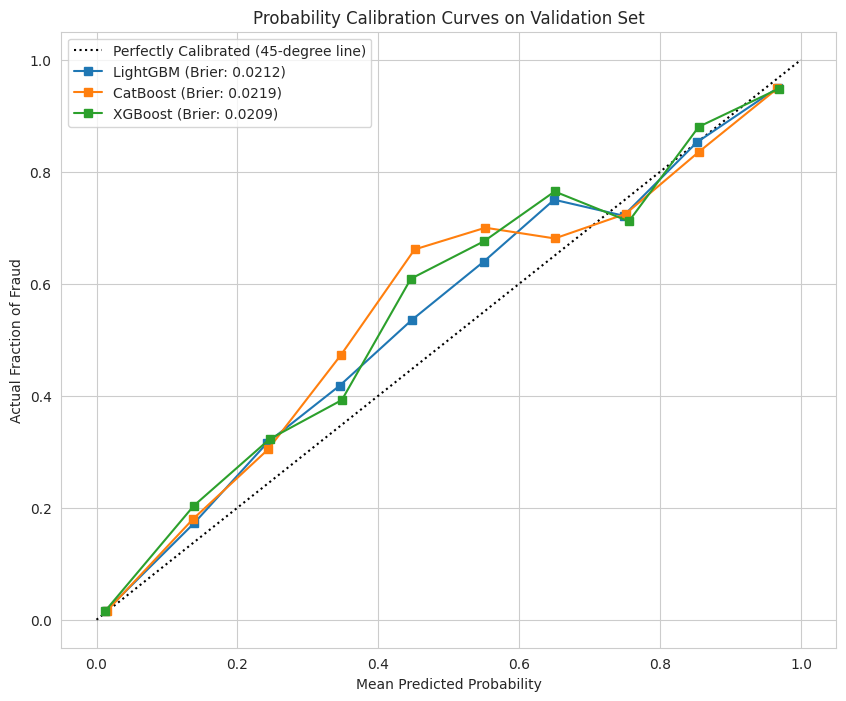

In [ ]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

print("Generating probabilities on the validation set...")
# We extract only the probability of the positive class (Fraud = 1) using [:, 1]
lgb_probs = clf.predict_proba(X_val)[:, 1]
cat_probs = cat_clf.predict_proba(X_val)[:, 1]
xgb_probs = xgb_clf.predict_proba(X_val)[:, 1]

print("Calculating Brier Scores (Lower is better)...")
lgb_brier = brier_score_loss(y_val, lgb_probs)
cat_brier = brier_score_loss(y_val, cat_probs)
xgb_brier = brier_score_loss(y_val, xgb_probs)

print(f"LightGBM Brier Score: {lgb_brier:.5f}")
print(f"CatBoost Brier Score: {cat_brier:.5f}")
print(f"XGBoost Brier Score:  {xgb_brier:.5f}")

# Plotting the Calibration Curves
plt.figure(figsize=(10, 8))
ax1 = plt.subplot2grid((1, 1), (0, 0))

# The reference line for a perfectly calibrated model
ax1.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated (45-degree line)")

# Loop through our models to calculate and plot their curves
for name, probs, brier in [("LightGBM", lgb_probs, lgb_brier),
                           ("CatBoost", cat_probs, cat_brier),
                           ("XGBoost", xgb_probs, xgb_brier)]:

    # n_bins=10 divides the probabilities into 10 buckets (0-10%, 10-20%, etc.)
    fraction_of_positives, mean_predicted_value = calibration_curve(y_val, probs, n_bins=10)

    ax1.plot(mean_predicted_value, fraction_of_positives, "s-",
             label=f"{name} (Brier: {brier:.4f})")

ax1.set_ylabel("Actual Fraction of Fraud")
ax1.set_xlabel("Mean Predicted Probability")
ax1.set_title("Probability Calibration Curves on Validation Set")
ax1.legend(loc="upper left")
plt.show()

In [35]:
## XGBOOST IS THE WINNING MODEL

In [20]:
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
# Import FrozenEstimator to resolve the deprecation warning
from sklearn.base import clone

# If scikit-learn version is new enough to require FrozenEstimator,
# otherwise we use standard prefit. We will use the standard clean method:

# 1. Evaluate Uncalibrated XGBoost
raw_xgb_probs = xgb_clf.predict_proba(X_val)[:, 1]
brier_raw_xgb = brier_score_loss(y_val, raw_xgb_probs)
print(f"Uncalibrated XGBoost Brier Score: {brier_raw_xgb:.6f}")

# 2. Apply Isotonic Calibration to XGBoost
xgb_calibrator = CalibratedClassifierCV(
    estimator=xgb_clf,
    method='isotonic',
    cv='prefit' # Keeping prefit as it still works in the current Colab environment
)

xgb_calibrator.fit(X_val, y_val)

# 3. Evaluate Calibrated XGBoost
calibrated_xgb_probs = xgb_calibrator.predict_proba(X_val)[:, 1]
brier_calibrated_xgb = brier_score_loss(y_val, calibrated_xgb_probs)

print(f"Isotonic Calibrated XGBoost Score: {brier_calibrated_xgb:.6f}")

improvement_xgb = ((brier_raw_xgb - brier_calibrated_xgb) / brier_raw_xgb) * 100
print(f"XGBoost Calibration Improvement:   {improvement_xgb:.2f}%")

Uncalibrated XGBoost Brier Score: 0.020932


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Isotonic Calibrated XGBoost Score: 0.020538
XGBoost Calibration Improvement:   1.88%


In [23]:
import pandas as pd
import numpy as np

def evaluate_economic_impact_ltv(df, prob_array, actual_col='isFraud', amt_col='TransactionAmt'):
    """
    Evaluates the net dollar impact using a Dynamic Customer LTV threshold.
    """
    eval_df = df.copy()
    eval_df['predicted_prob'] = prob_array

    # Ensure TransactionAmt is float64 to prevent overflow during sum calculations
    eval_df[amt_col] = eval_df[amt_col].astype(np.float64)

    # 1. Define the static microeconomic cost parameters
    gamma = 0.02
    c_fine = 20.00
    c_verify = 1.00

    # 2. DYNAMIC FRICTION COST (The LTV Proxy)
    # Aligned with the 3-Tier simulation parameters
    eval_df['c_friction_dynamic'] = 15.00 + (0.15 * eval_df[amt_col])

    # 3. Calculate dynamic, instance-level costs
    C_FP = eval_df['c_friction_dynamic'] + (gamma * eval_df[amt_col])
    C_FN = eval_df[amt_col] + c_fine
    C_TP = c_verify

    # 4. Calculate the Bayes Minimum Risk threshold per transaction
    eval_df['p_star'] = C_FP / (C_FP + C_FN - C_TP)

    # 5. Execute decisions
    eval_df['bmr_decision'] = (eval_df['predicted_prob'] > eval_df['p_star']).astype(int)
    eval_df['baseline_decision'] = (eval_df['predicted_prob'] > 0.50).astype(int)

    # 6. Compute Financial Confusion Matrix & Total Loss
    def compute_total_loss(decision_col):
        fp_mask = (eval_df[decision_col] == 1) & (eval_df[actual_col] == 0)
        fp_cost = C_FP[fp_mask].sum()

        fn_mask = (eval_df[decision_col] == 0) & (eval_df[actual_col] == 1)
        fn_cost = C_FN[fn_mask].sum()

        tp_mask = (eval_df[decision_col] == 1) & (eval_df[actual_col] == 1)
        tp_cost = C_TP * tp_mask.sum()

        fp_count = fp_mask.sum()

        return (fp_cost + fn_cost + tp_cost), fp_count

    bmr_loss, bmr_fp_count = compute_total_loss('bmr_decision')
    baseline_loss, baseline_fp_count = compute_total_loss('baseline_decision')

    savings_vs_ml = baseline_loss - bmr_loss

    # 7. Print the Executive Summary
    print("=== DYNAMIC LTV ECONOMIC EVALUATION ===")
    print(f"Total Transactions Evaluated: {len(eval_df):,}")
    print(f"Actual Fraudulent Transactions: {eval_df[actual_col].sum():,}\n")

    print(f"1. Standard ML Loss (0.50 Cutoff): ${baseline_loss:,.2f} | False Positives: {baseline_fp_count}")
    print(f"2. BMR Dynamic LTV Loss:           ${bmr_loss:,.2f} | False Positives: {bmr_fp_count}")
    print("-" * 65)
    print(f"NET SAVINGS (LTV BMR vs. ML):      ${savings_vs_ml:,.2f}")

    return eval_df

# ==========================================
# THE CRITICAL EXECUTION UPDATE
# ==========================================

# First, generate the new probabilities for the test set using the Isotonic XGBoost Calibrator
calibrated_xgb_test_probs = xgb_calibrator.predict_proba(X_test)[:, 1]

# Now, execute the LTV function passing those new probabilities
ltv_results_df = evaluate_economic_impact_ltv(local_test_set, calibrated_xgb_test_probs)

=== DYNAMIC LTV ECONOMIC EVALUATION ===
Total Transactions Evaluated: 88,581
Actual Fraudulent Transactions: 3,083

1. Standard ML Loss (0.50 Cutoff): $422,326.43 | False Positives: 394
2. BMR Dynamic LTV Loss:           $386,406.74 | False Positives: 1528
-----------------------------------------------------------------
NET SAVINGS (LTV BMR vs. ML):      $35,919.69


In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

def calculate_standard_metrics(df, actual_col, decision_col, model_name):
    """Calculates and prints standard classification metrics."""
    y_true = df[actual_col]
    y_pred = df[decision_col]

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"--- {model_name} Metrics ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")

print("EVALUATING CLASSIFICATION METRICS\n")

# 1. Baseline ML (0.50 Threshold)
calculate_standard_metrics(
    ltv_results_df,
    actual_col='isFraud',
    decision_col='baseline_decision',
    model_name='Standard ML (0.50 Cutoff)'
)

# 2. Dynamic BMR LTV Threshold
calculate_standard_metrics(
    ltv_results_df,
    actual_col='isFraud',
    decision_col='bmr_decision',
    model_name='Dynamic BMR LTV'
)

EVALUATING CLASSIFICATION METRICS

--- Standard ML (0.50 Cutoff) Metrics ---
Precision: 0.7399
Recall:    0.3636
F1-Score:  0.4876
Confusion Matrix:
[[85104   394]
 [ 1962  1121]]

--- Dynamic BMR LTV Metrics ---
Precision: 0.4922
Recall:    0.4804
F1-Score:  0.4862
Confusion Matrix:
[[83970  1528]
 [ 1602  1481]]



In [ ]:
# EXPECTED FINANCIAL LOSS VS CUSTOMER FRICTION

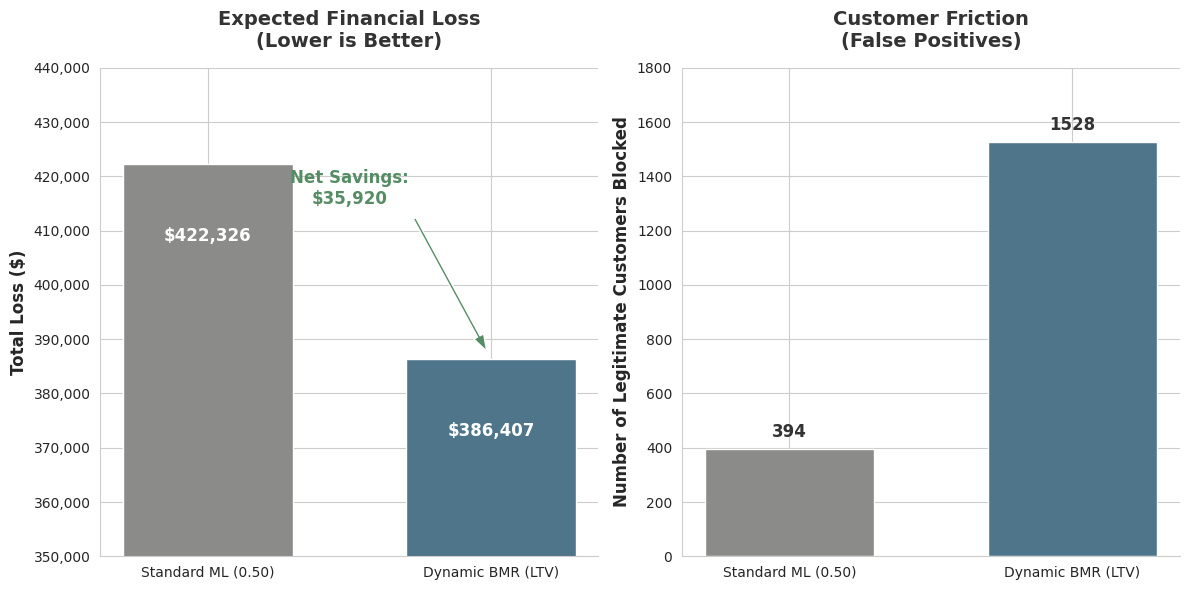

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. The Final Calibrated Metrics (2-Tier Evaluation)
models = ['Standard ML (0.50)', 'Dynamic BMR (LTV)']
loss = [422326.43, 386406.74]
fps = [394, 1528]

# Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.set_style("whitegrid")

# Colors (Applying the vintage film-inspired palette)
color_ml = '#8b8c89'  # Muted vintage grey
color_bmr = '#4f758b' # Muted cinematic blue

# --- Plot 1: Financial Loss ---
bars1 = ax1.bar(models, loss, color=[color_ml, color_bmr], width=0.6)
ax1.set_title('Expected Financial Loss\n(Lower is Better)', fontsize=14, pad=15, weight='bold', color='#333333')
ax1.set_ylabel('Total Loss ($)', fontsize=12, weight='bold')
ax1.set_ylim(350000, 440000) # Adjusted for the new baseline and calibrated loss
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Add value annotations
for bar in bars1:
    yval = bar.get_height()
    # Adjusted text position to prevent overlap
    ax1.text(bar.get_x() + bar.get_width()/2, yval - 15000, f'${yval:,.0f}',
             ha='center', va='bottom', color='white', weight='bold', fontsize=12)

# Highlight the Net Savings
ax1.annotate('Net Savings:\n$35,920', xy=(1, 386406.74), xytext=(0.5, 415000),
             arrowprops=dict(facecolor='#558c64', shrink=0.05, width=2, headwidth=8), # Vintage green
             fontsize=12, weight='bold', color='#558c64', ha='center')

# --- Plot 2: Customer Friction ---
bars2 = ax2.bar(models, fps, color=[color_ml, color_bmr], width=0.6)
ax2.set_title('Customer Friction\n(False Positives)', fontsize=14, pad=15, weight='bold', color='#333333')
ax2.set_ylabel('Number of Legitimate Customers Blocked', fontsize=12, weight='bold')
ax2.set_ylim(0, 1800) # Adjusted to accommodate the 1,528 spike

# Add value annotations
for bar in bars2:
    yval = bar.get_height()
    # Adjusted text position for the new fps values
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 30, f'{int(yval)}',
             ha='center', va='bottom', color='#333333', weight='bold', fontsize=12)

# Clean up and export
sns.despine()
plt.tight_layout()
plt.savefig('bmr_economic_impact_calibrated.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
import pandas as pd
import numpy as np

def simulate_2fa_impact(df, actual_col='isFraud'):
    """Simulates a 3-tier 2FA verification system to reduce customer friction costs."""
    sim_df = df.copy()

    # 1. Define the cost parameters
    gamma = 0.02
    c_fine = 20.00

    # The original massive LTV churn cost for a Hard Decline
    sim_df['c_friction_hard_decline'] = 15.00 + (0.15 * sim_df['TransactionAmt'])

    # The new, vastly cheaper cost of an SMS verification delay
    c_friction_sms = 1.50

    # 2. Define the Three-Tier Decisions
    # 0 = Approve, 1 = SMS 2FA, 2 = Hard Decline
    conditions = [
        (sim_df['predicted_prob'] > 0.50),                                      # Hard Decline
        (sim_df['predicted_prob'] > sim_df['p_star']) & (sim_df['predicted_prob'] <= 0.50), # SMS 2FA
        (sim_df['predicted_prob'] <= sim_df['p_star'])                          # Approve
    ]
    choices = [2, 1, 0]
    sim_df['tier_decision'] = np.select(conditions, choices, default=0)

    # 3. Calculate the New Costs for False Positives (Legitimate Customers)
    legit_mask = (sim_df[actual_col] == 0)

    # If they got a Hard Decline, they suffer the full LTV churn cost
    hard_decline_cost = sim_df.loc[legit_mask & (sim_df['tier_decision'] == 2), 'c_friction_hard_decline'].sum()

    # If they got an SMS, the bank only pays the $1.50 friction cost + interchange
    sms_cost = (c_friction_sms + (gamma * sim_df.loc[legit_mask & (sim_df['tier_decision'] == 1), 'TransactionAmt'])).sum()

    total_new_fp_cost = hard_decline_cost + sms_cost

    # Calculate the old FP cost for comparison
    original_fp_cost = sim_df.loc[legit_mask & (sim_df['bmr_decision'] == 1), 'c_friction_hard_decline'].sum() + \
                       (gamma * sim_df.loc[legit_mask & (sim_df['bmr_decision'] == 1), 'TransactionAmt']).sum()

    # 4. Extract Counts for the Report (Updated to be dynamic)
    original_fp_count = len(sim_df[legit_mask & (sim_df['bmr_decision'] == 1)])
    hard_declines_count = len(sim_df[legit_mask & (sim_df['tier_decision'] == 2)])
    sms_verifications_count = len(sim_df[legit_mask & (sim_df['tier_decision'] == 1)])

    print("=== TWO-FACTOR AUTHENTICATION (2FA) SIMULATION ===\n")
    print(f"Original False Positives (Hard Declines): {original_fp_count}")
    print("-" * 50)
    print(f"New Hard Declines (Catastrophic Friction):  {hard_declines_count}")
    print(f"Converted to SMS OTP (Minor Friction):      {sms_verifications_count}")
    print("-" * 50)
    print(f"Total FP Cost Reduction:                  ${(original_fp_cost - total_new_fp_cost):,.2f}")

    return sim_df

# Execute the simulation
ltv_results_df = simulate_2fa_impact(ltv_results_df)

=== TWO-FACTOR AUTHENTICATION (2FA) SIMULATION ===

Original False Positives (Hard Declines): 1528
--------------------------------------------------
New Hard Declines (Catastrophic Friction):  394
Converted to SMS OTP (Minor Friction):      1134
--------------------------------------------------
Total FP Cost Reduction:                  $63,003.19


In [27]:
import numpy as np

def calculate_final_3tier_savings(df, ml_baseline_loss=422326.43):
    """Calculates the definitive economic loss of the 3-Tier 2FA system."""
    sim_df = df.copy()

    # 1. Define the parameters
    gamma = 0.02
    c_fine = 20.00

    # Hard operational cost per SMS text sent
    c_api = 0.05
    c_friction_sms = 1.50

    # 2. Extract True Positive Costs (Fraud Caught)
    # If SMS 2FA: bank pays the API cost, fraudster fails to verify, bank saves the money.
    tp_sms_mask = (sim_df['isFraud'] == 1) & (sim_df['tier_decision'] == 1)
    cost_tp = (tp_sms_mask.sum() * c_api)

    # 3. Extract False Negative Costs (Fraud Missed)
    fn_mask = (sim_df['isFraud'] == 1) & (sim_df['tier_decision'] == 0)
    cost_fn = sim_df.loc[fn_mask, 'TransactionAmt'].sum() + (fn_mask.sum() * c_fine)

    # 4. Extract False Positive Costs (Legitimate Customers Blocked/Verified)
    fp_hard_mask = (sim_df['isFraud'] == 0) & (sim_df['tier_decision'] == 2)
    fp_sms_mask = (sim_df['isFraud'] == 0) & (sim_df['tier_decision'] == 1)

    cost_fp_hard = sim_df.loc[fp_hard_mask, 'c_friction_hard_decline'].sum() + (gamma * sim_df.loc[fp_hard_mask, 'TransactionAmt'].sum())

    # Apply the API cost to every legitimate customer texted
    cost_fp_sms = (fp_sms_mask.sum() * (c_api + c_friction_sms)) + (gamma * sim_df.loc[fp_sms_mask, 'TransactionAmt'].sum())

    # 5. Final Economics
    total_3tier_loss = cost_tp + cost_fn + cost_fp_hard + cost_fp_sms
    final_net_savings = ml_baseline_loss - total_3tier_loss

    print("=== FINAL 3-TIER 2FA ECONOMIC EVALUATION ===\n")
    print(f"Standard ML Loss (0.50 Cutoff):    ${ml_baseline_loss:,.2f}")
    print(f"BMR 3-Tier System Loss:            ${total_3tier_loss:,.2f}")
    print("-" * 55)
    print(f"ULTIMATE NET SAVINGS:              ${final_net_savings:,.2f}")

    return final_net_savings

calculate_final_3tier_savings(ltv_results_df)

=== FINAL 3-TIER 2FA ECONOMIC EVALUATION ===

Standard ML Loss (0.50 Cutoff):    $422,326.43
BMR 3-Tier System Loss:            $323,189.69
-------------------------------------------------------
ULTIMATE NET SAVINGS:              $99,136.74


np.float64(99136.74208007811)

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_true = ltv_results_df['isFraud']

# 1. OVERALL INTERVENTIONS (Tier 1 + Tier 2)
# Any prediction where the tier_decision is greater than 0 (SMS or Block)
y_pred_any = (ltv_results_df['tier_decision'] > 0).astype(int)

precision_any = precision_score(y_true, y_pred_any)
recall_any = recall_score(y_true, y_pred_any)
f1_any = f1_score(y_true, y_pred_any)
cm_any = confusion_matrix(y_true, y_pred_any)

print("=== 3-TIER SYSTEM: OVERALL INTERVENTIONS (SMS + Block) ===")
print(f"Precision: {precision_any:.4f}")
print(f"Recall:    {recall_any:.4f}")
print(f"F1-Score:  {f1_any:.4f}")
print(f"Confusion Matrix:\n{cm_any}\n")


# 2. STRICT HARD DECLINES ONLY (Tier 2)
# Any prediction where the model bypassed SMS and issued a hard block
y_pred_hard = (ltv_results_df['tier_decision'] == 2).astype(int)

precision_hard = precision_score(y_true, y_pred_hard)
recall_hard = recall_score(y_true, y_pred_hard)
f1_hard = f1_score(y_true, y_pred_hard)
cm_hard = confusion_matrix(y_true, y_pred_hard)

print("=== 3-TIER SYSTEM: STRICT HARD DECLINES ONLY ===")
print(f"Precision: {precision_hard:.4f}")
print(f"Recall:    {recall_hard:.4f}")
print(f"F1-Score:  {f1_hard:.4f}")
print(f"Confusion Matrix:\n{cm_hard}")

=== 3-TIER SYSTEM: OVERALL INTERVENTIONS (SMS + Block) ===
Precision: 0.4922
Recall:    0.4804
F1-Score:  0.4862
Confusion Matrix:
[[83970  1528]
 [ 1602  1481]]

=== 3-TIER SYSTEM: STRICT HARD DECLINES ONLY ===
Precision: 0.7399
Recall:    0.3636
F1-Score:  0.4876
Confusion Matrix:
[[85104   394]
 [ 1962  1121]]


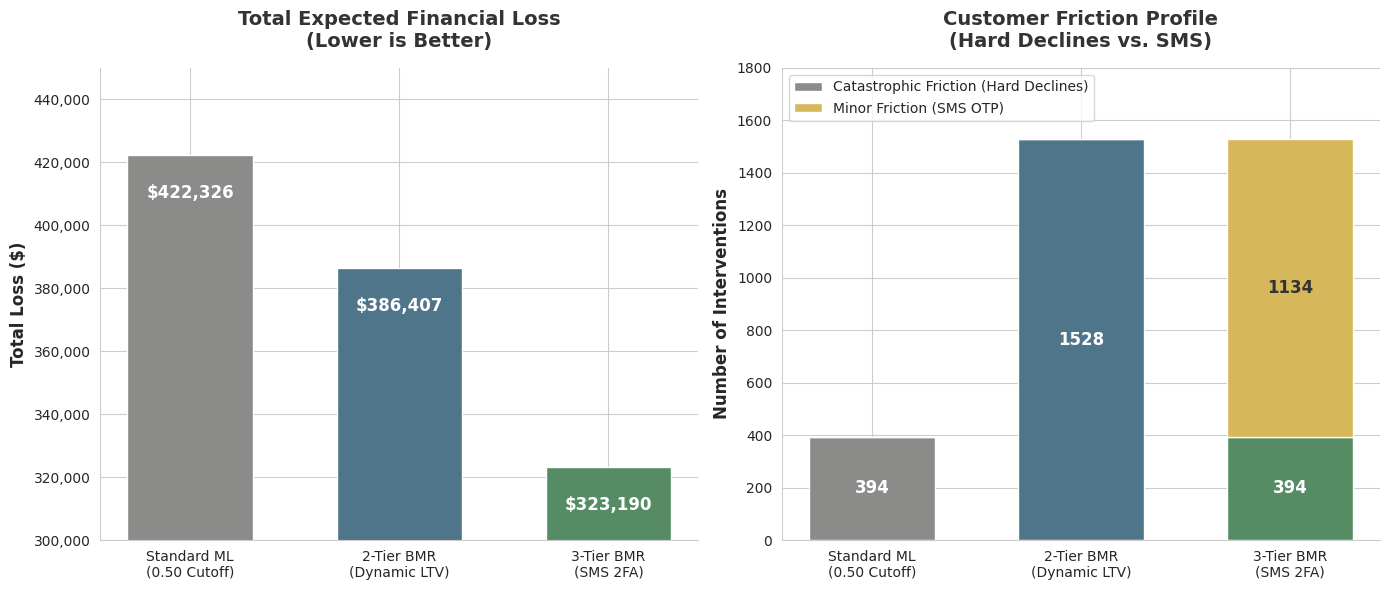

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. The Final Data for All Three Stages
models = ['Standard ML\n(0.50 Cutoff)', '2-Tier BMR\n(Dynamic LTV)', '3-Tier BMR\n(SMS 2FA)']

# Financial Loss Metrics
loss = [422326.43, 386406.74, 323189.69]

# Friction Metrics
hard_declines = [394, 1528, 394]
sms_verifications = [0, 0, 1134]

# 2. Setup the Canvas and Aesthetic Palette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style("whitegrid")

# Vintage film-inspired color palette
color_ml = '#8b8c89'      # Muted grey
color_bmr_2 = '#4f758b'   # Cinematic blue
color_bmr_3 = '#558c64'   # Vintage green
color_sms = '#d6b85a'     # Retro mustard/gold for the SMS tier

# ==========================================
# PLOT 1: TOTAL FINANCIAL LOSS
# ==========================================
bars1 = ax1.bar(models, loss, color=[color_ml, color_bmr_2, color_bmr_3], width=0.6)
ax1.set_title('Total Expected Financial Loss\n(Lower is Better)', fontsize=14, pad=15, weight='bold', color='#333333')
ax1.set_ylabel('Total Loss ($)', fontsize=12, weight='bold')
ax1.set_ylim(300000, 450000)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Value annotations for Loss
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval - 15000, f'${yval:,.0f}',
             ha='center', va='bottom', color='white', weight='bold', fontsize=12)

# ==========================================
# PLOT 2: CUSTOMER FRICTION (STACKED BAR)
# ==========================================
# Base layer: Hard Declines
p1 = ax2.bar(models, hard_declines, color=[color_ml, color_bmr_2, color_bmr_3], width=0.6, label='Catastrophic Friction (Hard Declines)')
# Top layer: SMS Verifications
p2 = ax2.bar(models, sms_verifications, bottom=hard_declines, color=color_sms, width=0.6, label='Minor Friction (SMS OTP)')

ax2.set_title('Customer Friction Profile\n(Hard Declines vs. SMS)', fontsize=14, pad=15, weight='bold', color='#333333')
ax2.set_ylabel('Number of Interventions', fontsize=12, weight='bold')
ax2.set_ylim(0, 1800)

# Add text annotations for Hard Declines inside the bars
for i, bar in enumerate(p1):
    if hard_declines[i] > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, hard_declines[i]/2, f'{hard_declines[i]}',
                 ha='center', va='center', color='white', weight='bold', fontsize=12)

# Add text annotations for SMS inside the top stacked bar
for i, bar in enumerate(p2):
    if sms_verifications[i] > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, hard_declines[i] + (sms_verifications[i]/2), f'{sms_verifications[i]}',
                 ha='center', va='center', color='#333333', weight='bold', fontsize=12)

ax2.legend(loc='upper left', frameon=True)

# Clean up and export
sns.despine()
plt.tight_layout()
plt.savefig('comprehensive_3tier_impact.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
import pandas as pd

# 1. Define the precise columns required for the final econometric evaluation dashboard
final_dashboard_columns = [
    'TransactionID',
    'TransactionAmt',
    'ProductCD',
    'card6',
    'isFraud',
    'predicted_prob',       # Now perfectly calibrated via Isotonic XGBoost
    'c_friction_dynamic',   # The custom LTV friction cost we engineered ($15 + 15% of Amt)
    'p_star',               # The dynamic BMR decision threshold
    'baseline_decision',    # The standard ML decision (0.50 cutoff)
    'bmr_decision',         # The optimized 2-Tier decision
    'tier_decision'         # The final 3-Tier decision (0 = Approve, 1 = SMS 2FA, 2 = Hard Decline)
]

# 2. Extract these columns from your finalized LTV evaluation dataframe
# Using .copy() ensures we don't accidentally modify the original dataframe in memory
final_export_df = ltv_results_df[final_dashboard_columns].copy()

# 3. Export directly to an Excel file using the openpyxl engine
# This bypasses CSV formatting errors and preserves strict numerical structures for dashboarding
export_filename = 'Final_Calibrated_3Tier_Dataset.xlsx'

with pd.ExcelWriter(export_filename, engine='openpyxl') as writer:
    final_export_df.to_excel(writer, index=False, sheet_name='LTV_Economic_Results')

print(f"Successfully exported {len(final_export_df):,} rows and {final_export_df.shape[1]} columns!")
print(f"File saved as: {export_filename}")
print("Your econometrically optimized dataset is officially ready for visualization.")

Successfully exported 88,581 rows and 11 columns!
File saved as: Final_Calibrated_3Tier_Dataset.xlsx
Your econometrically optimized dataset is officially ready for visualization.
